# 2.3 ΕΠΕΞΕΡΓΑΣΙΑ ΜΕΤΡΗΣΕΩΝ ΕΡΓΑΣΤΗΡΙΟΥ 2

## 2.3.1 𝜤𝒊𝒏(𝒕) και 𝑽𝒐𝒖𝒕(𝒕) του αισθητήρα

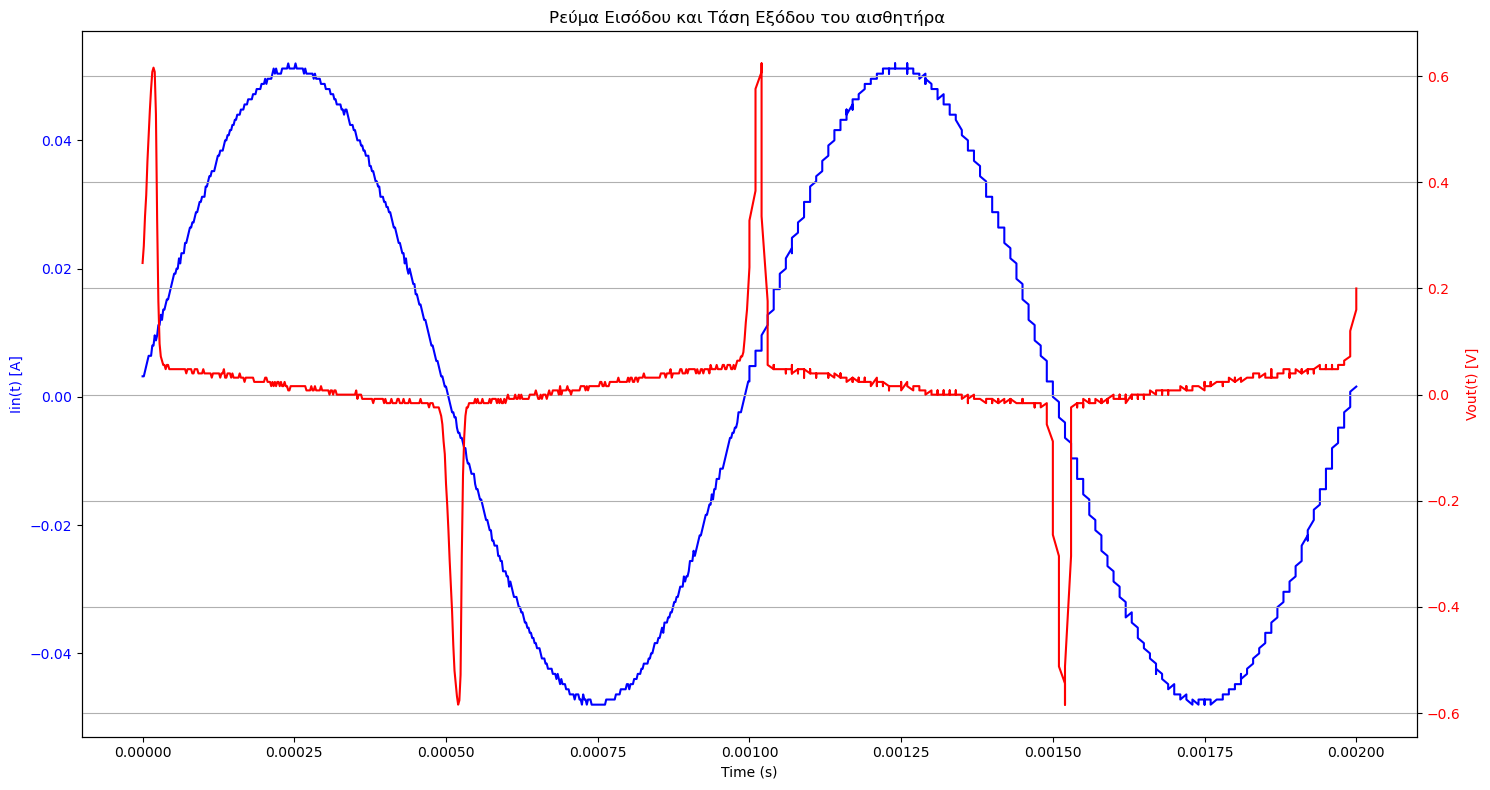

In [10]:
import csv
import numpy as np
import matplotlib.pyplot as plt

with open(r'C:\Users\akots\OneDrive\Desktop\sensolab2_data.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader) 

    time, vin, vout = [], [], []
    for row in reader:
        if len(row) < 3:
            continue
        time.append(float(row[0].replace(',', '.')))
        vin.append(float(row[1].replace(',', '.')))
        vout.append(float(row[2].replace(',', '.')))


t = np.array(time)       
vin = np.array(vin)      
vout = np.array(vout)    
R = 100  
iin = vin / R

fig, ax1 = plt.subplots(figsize=(15, 8))
ax1.plot(t, iin, color='blue', label='Input Current Iin(t) [A]')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Iin(t) [A]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
ax2.plot(t, vout, color='red', label='Output Voltage Vout(t) [V]')
ax2.set_ylabel('Vout(t) [V]', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Ρεύμα Εισόδου και Τάση Εξόδου του αισθητήρα ')
fig.tight_layout()
plt.grid()
plt.show()



## 2.3.3 - Ολοκλήρωμα των τιμών της τάσης εξόδου

Integral of Vout(t):
[ 0.     0.264  0.572  0.928  1.336  1.8    2.312  2.868  3.46   4.072
  4.684  5.252  5.68   5.932  6.068  6.152  6.22   6.28   6.336  6.388
  6.44   6.496  6.548  6.596  6.644  6.692  6.74   6.788  6.836  6.884
  6.932  6.98   7.028  7.076  7.124  7.172  7.216  7.26   7.308  7.356
  7.404  7.448  7.488  7.532  7.58   7.628  7.672  7.712  7.752  7.792
  7.836  7.88   7.92   7.96   8.     8.04   8.08   8.116  8.152  8.192
  8.232  8.272  8.312  8.352  8.388  8.424  8.464  8.508  8.548  8.58
  8.616  8.656  8.696  8.732  8.768  8.804  8.836  8.868  8.9    8.932
  8.968  9.004  9.036  9.068  9.096  9.124  9.156  9.188  9.22   9.252
  9.284  9.316  9.344  9.368  9.392  9.416  9.44   9.464  9.488  9.512
  9.536  9.564  9.596  9.624  9.648  9.672  9.692  9.712  9.732  9.752
  9.772  9.792  9.816  9.836  9.856  9.876  9.892  9.912  9.932  9.948
  9.96   9.968  9.98   9.996 10.012 10.028 10.044 10.06  10.076 10.092
 10.108 10.124 10.14  10.156 10.172 10.184 10.192 10.2   

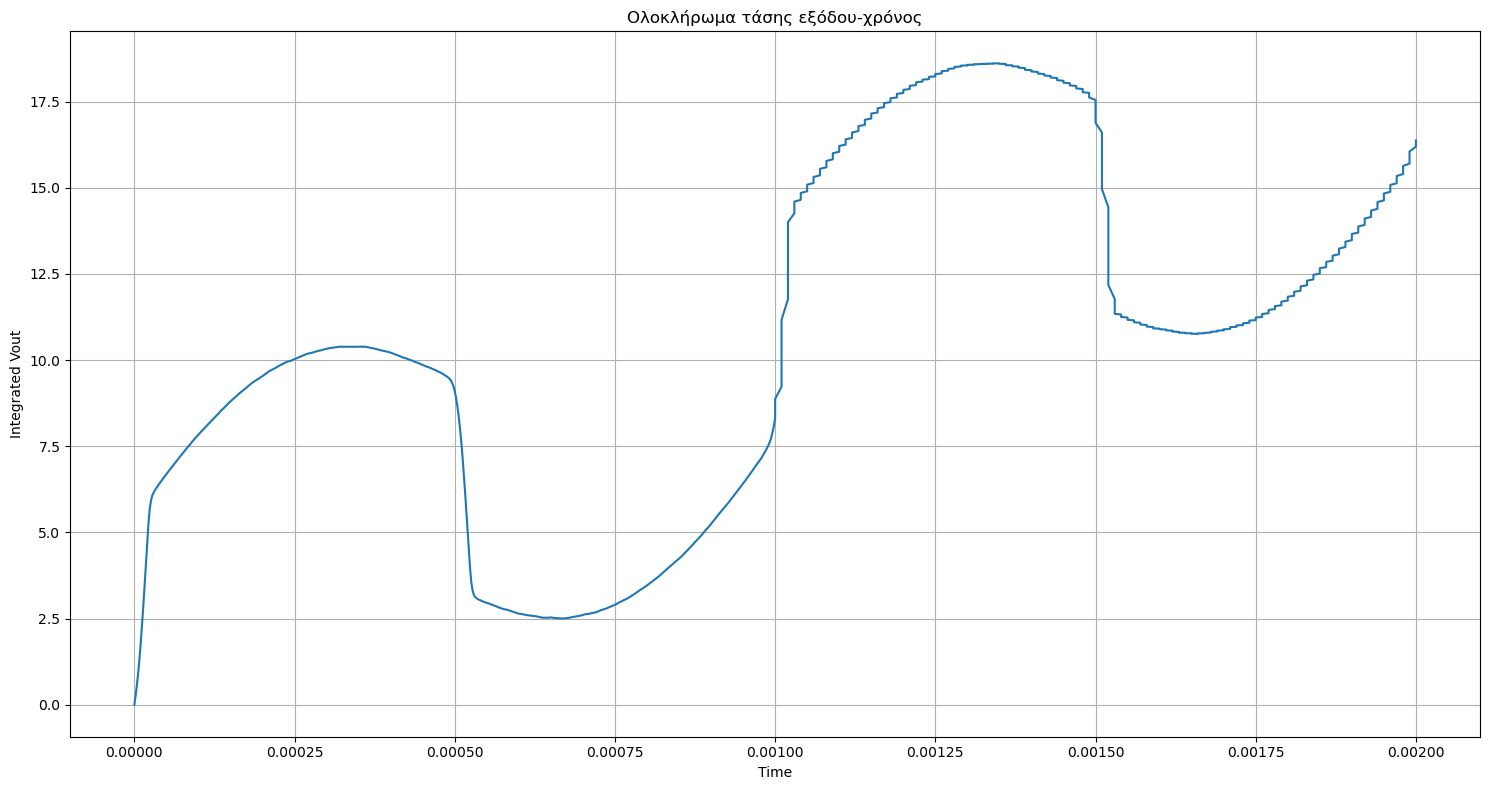

In [8]:
import numpy as np
import csv
import matplotlib.pyplot as plt
    
dt = 1  
integral = np.cumsum((vout[:-1] + vout[1:]) / 2) * dt
integral = np.insert(integral, 0, 0)  

print("Integral of Vout(t):")
print(integral)

plt.figure(figsize=(15, 8))
plt.plot(t, integral, label='Ολοκλήρωμα τάσης εξόδου-χρόνος')
plt.xlabel('Time')
plt.ylabel('Integrated Vout')
plt.title('Ολοκλήρωμα τάσης εξόδου-χρόνος')
plt.grid(True)
plt.tight_layout()
plt.show()



## 2.3.4 Βρόχος υστέρησης

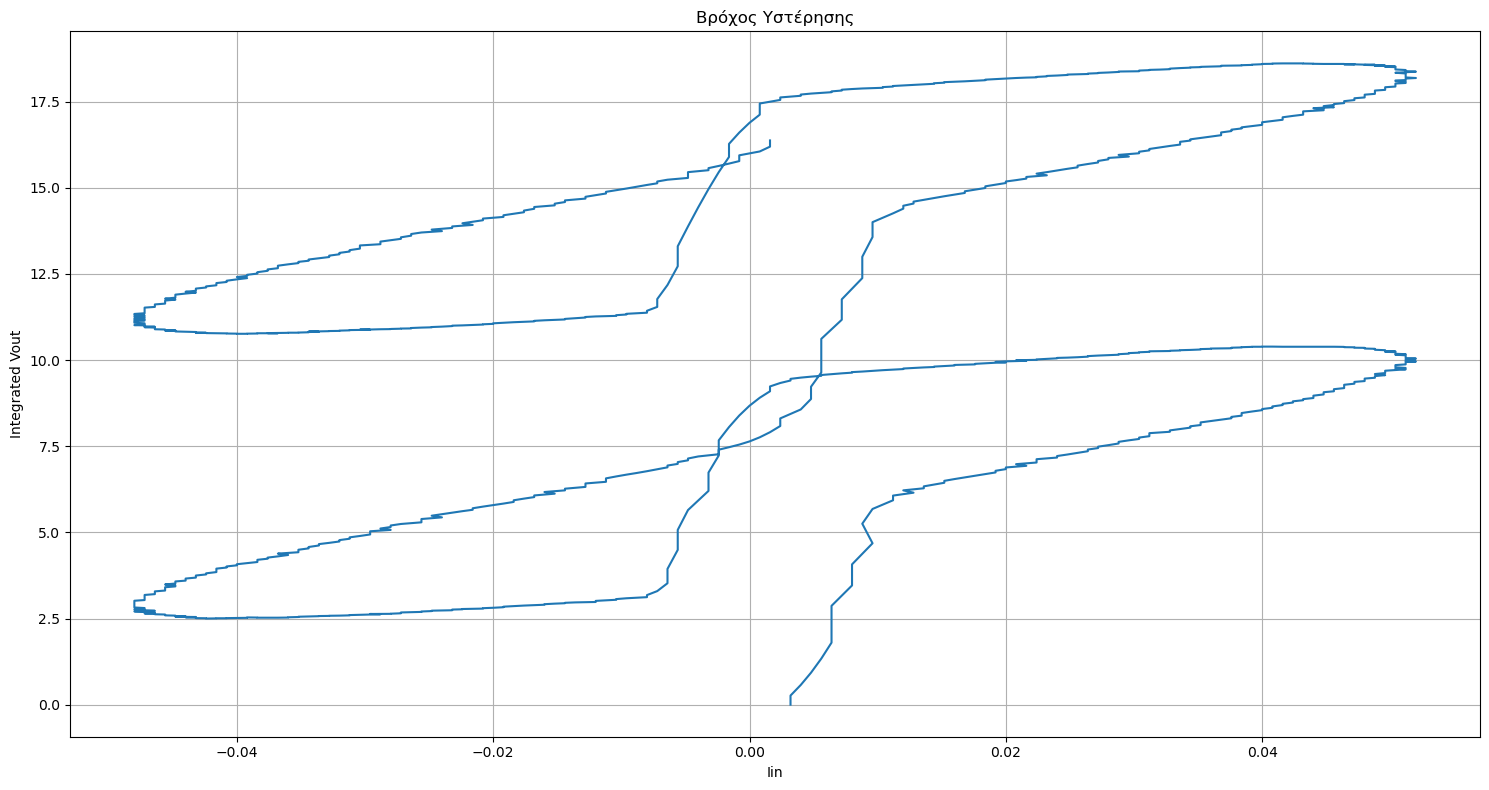

In [7]:

plt.figure(figsize=(15, 8))
plt.plot(iin, integral)
plt.xlabel('Ιin')
plt.ylabel('Integrated Vout')
plt.title('Βρόχος Υστέρησης')
plt.grid(True)
plt.tight_layout()
plt.show()